In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


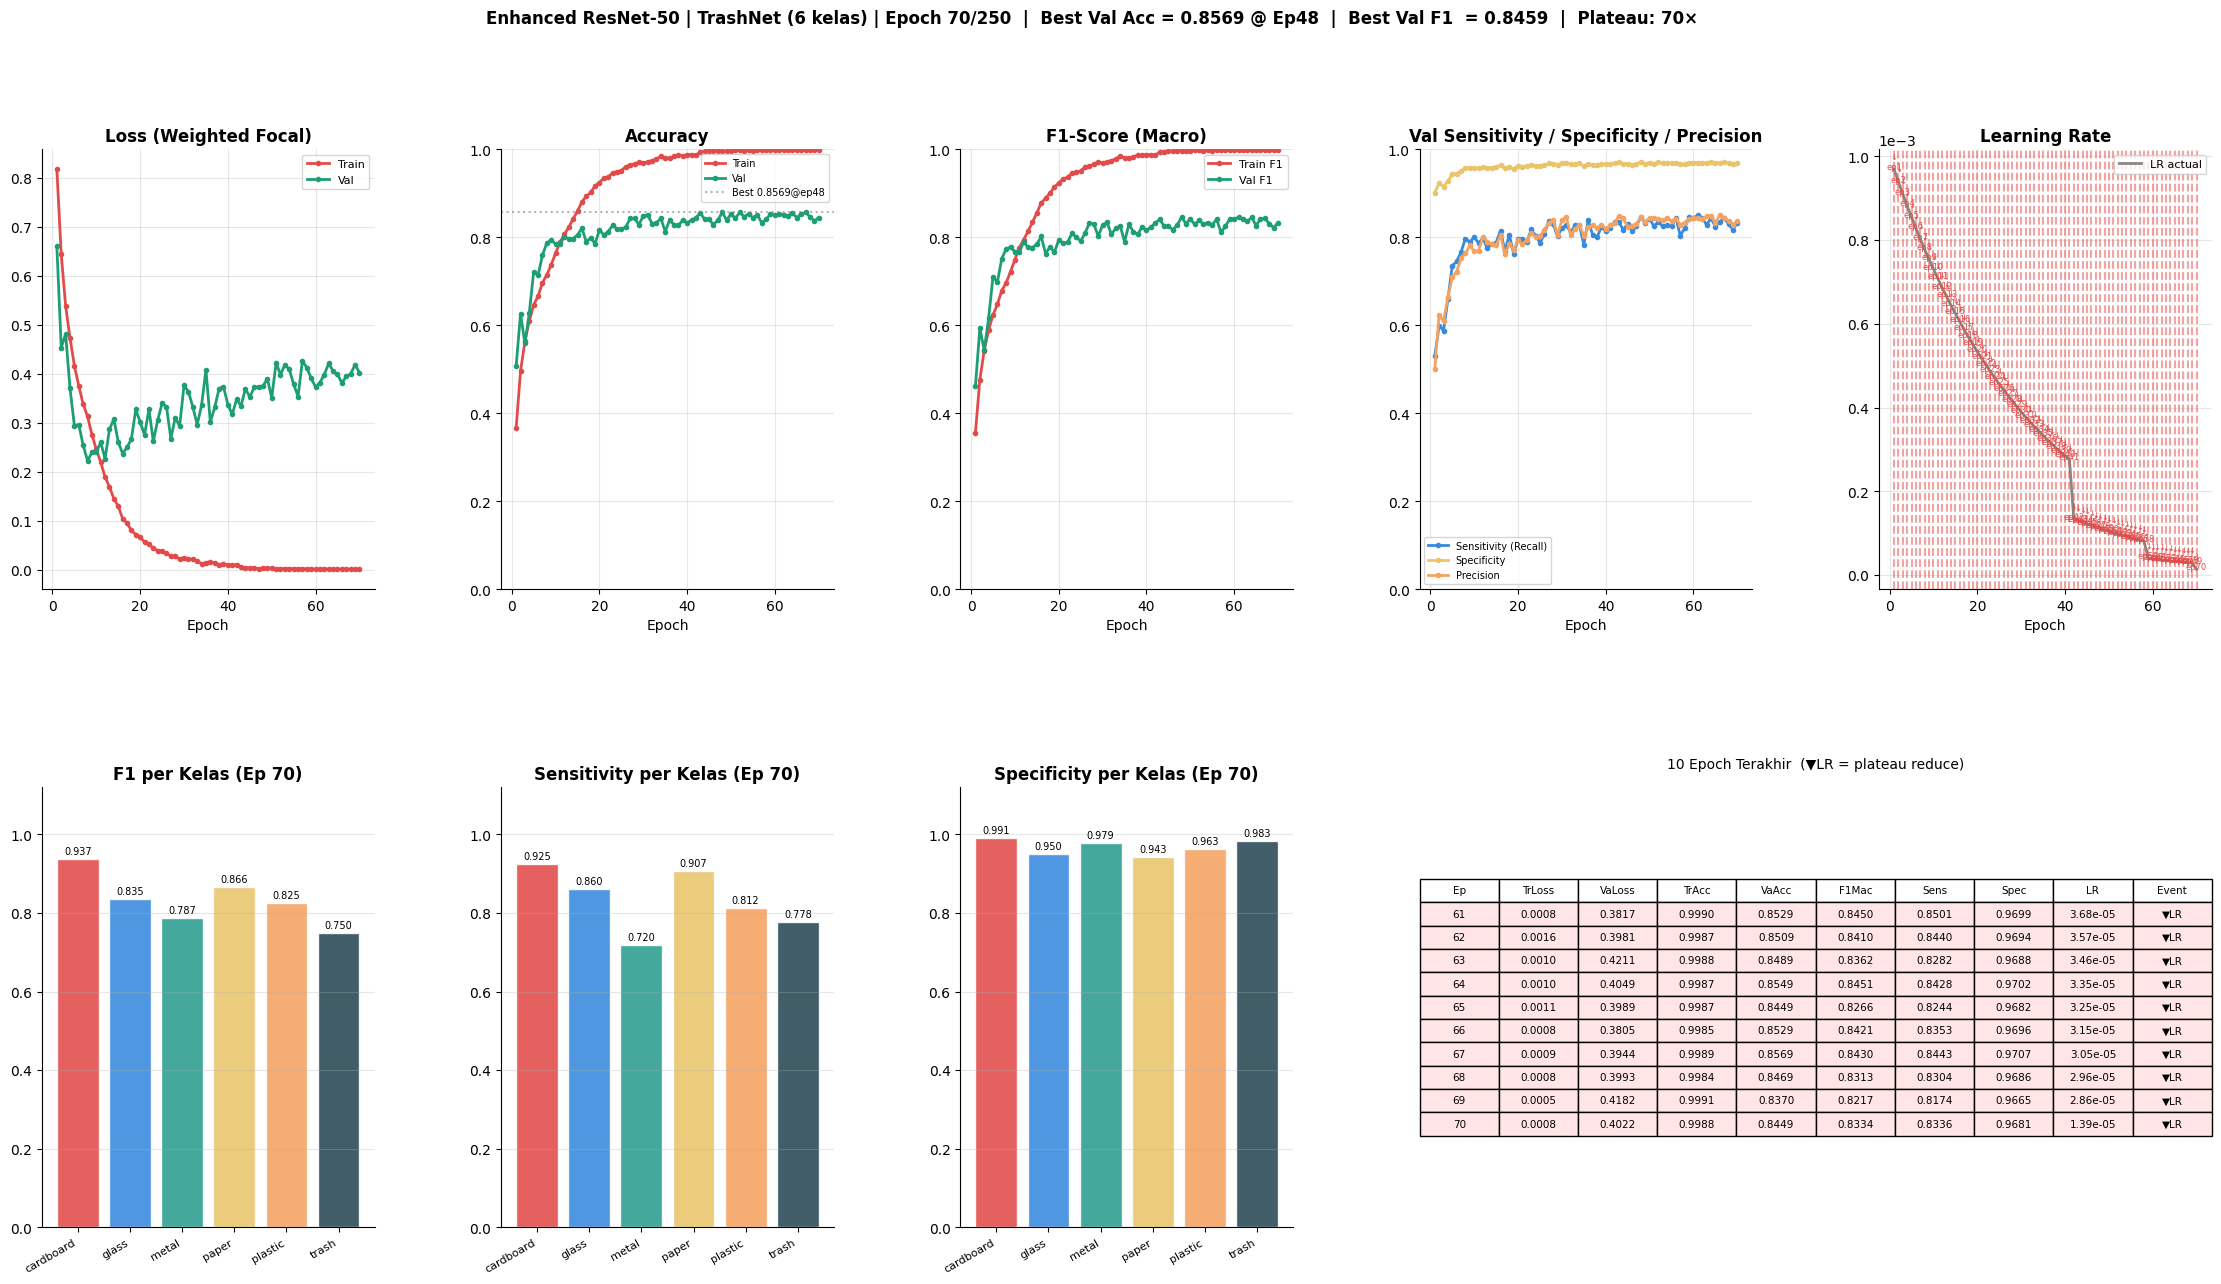


  Epoch  71/250  |  LR: 1.39e-05


  [16:42:10] [PLATEAU] Ep 071: LR 1.39e-05 → 1.34e-05 (Val Acc=0.8390)
  Train | Loss=0.0004  Acc=0.9994  F1=0.9994
  Val   | Loss=0.3990  Acc=0.8390  F1=0.8297  Sens=0.8285  Spec=0.9669 [▼PLATEAU]  [no improve: 23/25]

  Epoch  72/250  |  LR: 1.34e-05


  [16:44:32] [PLATEAU] Ep 072: LR 1.34e-05 → 1.30e-05 (Val Acc=0.8549)
  Train | Loss=0.0007  Acc=0.9990  F1=0.9990
  Val   | Loss=0.3909  Acc=0.8549  F1=0.8460  Sens=0.8513  Spec=0.9703 [▼PLATEAU]  [no improve: 24/25]

  Epoch  73/250  |  LR: 1.30e-05


  [16:46:55] [PLATEAU] Ep 073: LR 1.30e-05 → 1.26e-05 (Val Acc=0.8509)
  Train | Loss=0.0005  Acc=0.9992  F1=0.9993
  Val   | Loss=0.3872  Acc=0.8509  F1=0.8408  Sens=0.8436  Spec=0.9695 [▼PLATEAU]  [no improve: 25/25]

  [Early Stop] Epoch 73: 25 epoch tanpa peningkatan. Best Val Acc=0.8569 @ Ep48
  [16:46:56] [Early Stop] Epoch 73: 25 epoch tanpa peningkatan. Best Val Acc=0.8569 @ Ep48

──────────────────────────────────────────────────────────────────────
  Menghitung rata-rata 10 epoch terakhir (sesuai paper)...

════════════════════════════════════════════════════════════════════════════════
                    FINAL TRAINING SUMMARY
════════════════════════════════════════════════════════════════════════════════
  Dataset         : TrashNet (6 kelas)
  Model           : Enhanced ResNet-50 (Li et al., PLoS ONE 2025)
  Best Val Acc    : 0.8569  @  Epoch 48
  Plateau Events  : 73  →  epochs [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2

  Evaluating: 100%|█████████████████████████████| 14/14 [00:02<00:00,  4.72it/s]



  ── Metrics (Best Model) ──
  Accuracy      : 0.8569
  F1 Macro      : 0.8459
  F1 Weighted   : 0.8568
  Sensitivity   : 0.8465
  Specificity   : 0.9708
  Precision     : 0.8457

  ── Per-Class ──
  Kelas              F1   Precision   Sensitivity   Specificity
  ────────────────────────────────────────────────────────────
  cardboard      0.9308      0.9367        0.9250        0.9882
  glass          0.8458      0.8416        0.8500        0.9603
  metal          0.8176      0.8442        0.7927        0.9715
  paper          0.8824      0.8750        0.8898        0.9610
  plastic        0.8351      0.8265        0.8438        0.9582
  trash          0.7636      0.7500        0.7778        0.9853

  ── Classification Report ──
              precision    recall  f1-score   support

   cardboard     0.9367    0.9250    0.9308        80
       glass     0.8416    0.8500    0.8458       100
       metal     0.8442    0.7927    0.8176        82
       paper     0.8750    0.8898    0.882

In [ ]:
# -*- coding: utf-8 -*-
"""
TrashNet_ResNet50_Enhanced.py
==============================
Paper     : "Enhanced ResNet-50 for garbage classification: Feature fusion
             and depth-separable convolutions"
            Li et al., PLoS ONE 20(1): e0317999, January 27, 2025

Dataset   : TrashNet — 6 kelas: cardboard, glass, metal, paper, plastic, trash
            Data sudah dipreprocessed: ../sampah/trashnet_preprocessed/
              ├── train/
              │     └── {kelas}/  (gambar original _orig + augmented _aug*)
              └── val/
                    └── {kelas}/  (gambar preprocessed saja)

MODEL     : Enhanced ResNet-50
            ├── Redundancy-Weighted Feature Fusion (conv1 diganti)
            │     Parallel 7×7, 5×5, 3×3 → subtract redundancy → concat + weights α,β,γ
            ├── Depth-Separable Convolution (semua 3×3 di bottleneck diganti)
            │     depthwise conv (per-channel) + pointwise conv (1×1)
            └── Pretrained backbone: torchvision ResNet-50 (ImageNet weights)

LOSS      : Weighted Focal Loss
            L = -(1/N) Σ δ_i · y_{i,c} · (1 - p_{i,c})^λ · log(p_{i,c})
            δ_i inversely proportional to class count (class-balancing weight)
            λ (gamma) = 2

OPTIMIZER : AdamW, lr=1e-3, weight_decay=1e-9
SCHEDULER : ExponentialLR (gamma=0.96^(1/1.3) per epoch) sesuai paper
            + ReduceLROnPlateau (monitoring val_accuracy, patience=10)
BATCH     : 12
EPOCHS    : 250
METRICS   : Accuracy, Loss, F1 (macro+per-class), Sensitivity (Recall),
            Specificity, Precision, Confusion Matrix, Classification Report
            → Evaluasi final: rata-rata 10 epoch terakhir (sesuai paper)

CALLBACKS : Live plot per epoch, CSV logger, TXT logger, Checkpoint (best),
            Early stopping, ReduceLROnPlateau

OUTPUT    : ../sampah/model/
              ├── best_model.pth               ← best val accuracy
              ├── last_model.pth               ← epoch terakhir
              ├── training_log.txt             ← human-readable log
              ├── training_log.csv             ← machine-readable per epoch
              ├── confusion_matrix_best.png    ← CM saat best epoch
              ├── classification_report.txt    ← report saat best epoch
              ├── live_plot.png                ← plot training (update tiap epoch)
              └── final_summary.png            ← ringkasan akhir

REFERENSI : Li L, Wang R, Zou M, Guo F, Ren Y (2025) PLoS ONE 20(1): e0317999
            https://doi.org/10.1371/journal.pone.0317999
"""

# ══════════════════════════════════════════════════════════════════════════════
# 1. IMPORT
# ══════════════════════════════════════════════════════════════════════════════
import os
import csv
import time
import random
import datetime
import warnings
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)
from tqdm import tqdm

try:
    from IPython.display import clear_output, display
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════════════════
# 2. CONFIG
# ══════════════════════════════════════════════════════════════════════════════

# ── Path ──────────────────────────────────────────────────────────────────────
DATA_ROOT  = '/content/drive/MyDrive/Belajar AI/sampah/trashnet_preprocessed'
SAVE_DIR   = '/content/drive/MyDrive/Belajar AI/sampah/model'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Kelas ─────────────────────────────────────────────────────────────────────
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASSES)

# ── Hyperparameter — sesuai paper ─────────────────────────────────────────────
IMG_SIZE        = 224          # input size VGG/ResNet standard
BATCH_SIZE      = 36           # paper: batch size 12
LR              = 1e-3         # paper: initial LR 1e-3
WEIGHT_DECAY    = 1e-9         # paper: weight decay 1e-9
MAX_EPOCHS      = 250          # paper: 250 epochs
FOCAL_GAMMA     = 2            # paper: λ=2 untuk Focal Loss
FINAL_AVG_K     = 10           # paper: rata-rata 10 epoch terakhir

# ExponentialLR: decays to 96% every 1.3 cycles
# gamma per epoch = 0.96^(1/1.3)
EXP_DECAY_RATE  = 0.96
EXP_CYCLE       = 1.3
EXP_GAMMA       = EXP_DECAY_RATE ** (1.0 / EXP_CYCLE)   # ≈ 0.9693

# ReduceLROnPlateau
PLATEAU_FACTOR    = 0.5
PLATEAU_PATIENCE  = 10
PLATEAU_MIN_LR    = 1e-7
PLATEAU_THRESHOLD = 1e-4

# Early stopping
EARLY_STOP_PATIENCE = 25       # lebih longgar karena paper train 250 ep penuh

# SCP Gate reduction (untuk ResNet feature fusion)
REDUCTION         = 4

# ── Seed ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42


def set_global_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f'[Seed] Global seed diset ke {seed}')


set_global_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[Device] {DEVICE}')


# ══════════════════════════════════════════════════════════════════════════════
# 3. LOGGER
# ══════════════════════════════════════════════════════════════════════════════

class TrainingLogger:
    """Logger untuk training: TXT + CSV, setiap epoch dicatat lengkap."""

    CSV_COLUMNS = [
        'epoch', 'phase',
        'loss', 'accuracy',
        'f1_macro', 'f1_weighted',
        'precision_macro', 'recall_macro',
        'specificity_macro',
        'lr_exp', 'lr_actual',
        'plateau_reduced', 'lr_before_plateau', 'lr_after_plateau',
        'is_best', 'elapsed_sec',
    ]

    def __init__(self, save_dir: str):
        self.save_dir     = save_dir
        self.txt_path     = os.path.join(save_dir, 'training_log.txt')
        self.csv_path     = os.path.join(save_dir, 'training_log.csv')
        self._csv_file    = open(self.csv_path, 'w', newline='')
        self._csv_writer  = csv.DictWriter(self._csv_file,
                                           fieldnames=self.CSV_COLUMNS)
        self._csv_writer.writeheader()
        self._csv_file.flush()
        self._epoch_start = None

        header = (
            '=' * 100 + '\n'
            '  Training Log — Enhanced ResNet-50 (Li et al., PLoS ONE 2025)\n'
            f'  Dataset       : TrashNet (6 kelas)\n'
            f'  Dimulai       : {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n'
            f'  Backbone      : ResNet-50 (ImageNet pretrained)\n'
            f'  Loss          : Weighted Focal Loss (γ={FOCAL_GAMMA})\n'
            f'  Optimizer     : AdamW (lr={LR}, wd={WEIGHT_DECAY})\n'
            f'  Scheduler     : ExponentialLR (γ={EXP_GAMMA:.4f}) + ReduceLROnPlateau\n'
            f'  Batch Size    : {BATCH_SIZE}  |  Max Epochs: {MAX_EPOCHS}\n'
            f'  Save Dir      : {save_dir}\n'
            '=' * 100 + '\n\n'
        )
        with open(self.txt_path, 'w') as f:
            f.write(header)

    def start_epoch(self):
        self._epoch_start = time.time()

    def log_epoch(self, epoch: int, phase: str, loss: float, metrics: dict,
                  lr_exp: float, lr_actual: float,
                  plateau_reduced: bool, lr_before: float, lr_after: float,
                  is_best: bool):
        elapsed = time.time() - self._epoch_start if self._epoch_start else 0.0
        row = {
            'epoch'               : epoch,
            'phase'               : phase,
            'loss'                : round(loss, 6),
            'accuracy'            : round(metrics.get('accuracy', 0), 4),
            'f1_macro'            : round(metrics.get('f1_macro', 0), 4),
            'f1_weighted'         : round(metrics.get('f1_weighted', 0), 4),
            'precision_macro'     : round(metrics.get('precision_macro', 0), 4),
            'recall_macro'        : round(metrics.get('recall_macro', 0), 4),
            'specificity_macro'   : round(metrics.get('specificity_macro', 0), 4),
            'lr_exp'              : f'{lr_exp:.2e}',
            'lr_actual'           : f'{lr_actual:.2e}',
            'plateau_reduced'     : int(plateau_reduced),
            'lr_before_plateau'   : f'{lr_before:.2e}',
            'lr_after_plateau'    : f'{lr_after:.2e}',
            'is_best'             : int(is_best),
            'elapsed_sec'         : round(elapsed, 1),
        }
        self._csv_writer.writerow(row)
        self._csv_file.flush()

    def log_event(self, msg: str):
        ts   = datetime.datetime.now().strftime('%H:%M:%S')
        line = f'  [{ts}] {msg}'
        with open(self.txt_path, 'a') as f:
            f.write(line + '\n')
        print(line)

    def log_txt(self, msg: str):
        with open(self.txt_path, 'a') as f:
            f.write(msg + '\n')

    def close(self):
        if self._csv_file:
            self._csv_file.close()


# ══════════════════════════════════════════════════════════════════════════════
# 4. MODEL — Enhanced ResNet-50
# ══════════════════════════════════════════════════════════════════════════════

# ── 4a. Depth-Separable Convolution ───────────────────────────────────────────
class DepthSeparableConv2d(nn.Module):
    """
    Depth-Separable Convolution = Depthwise 3×3 + Pointwise 1×1.
    Mengganti standard 3×3 Conv di bottleneck ResNet-50.

    Parameter reduction vs standard 3×3 Conv:
      Standard   : 3×3×C×C₁  (= 9·C·C₁)
      DS Conv    : 3×3×C + C×C₁  (= C·(9 + C₁))
    Ratio        : (9+C₁) / (9·C₁)  << 1 untuk C₁ >> 1
    """
    def __init__(self, in_channels: int, out_channels: int,
                 stride: int = 1, padding: int = 1):
        super().__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, stride=stride, padding=padding,
            groups=in_channels, bias=False          # per-channel
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, stride=1, padding=0,
            bias=False                              # cross-channel
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


# ── 4b. Redundancy-Weighted Feature Fusion (conv1 replacement) ────────────────
class RedundancyWeightedFeatureFusion(nn.Module):
    """
    Mengganti layer conv1 (7×7) ResNet-50 dengan multi-scale feature fusion.

    Pipeline:
      Input x: (B, 3, 224, 224)
      ├─ Conv7×7, 64, stride=2 → Feature₁ = Conv₇ₓ₇(x)
      ├─ Conv5×5, 64, stride=2 → Feature₂ = Conv₅ₓ₅(x) − Conv₇ₓ₇(x)  [redundancy removed]
      └─ Conv3×3, 64, stride=2 → Feature₃ = Conv₃ₓ₃(x) − Conv₅ₓ₅(x)  [redundancy removed]
      Output = Concat[α·F₁, β·F₂, γ·F₃] → (B, 192, 112, 112)
      Followed by 1×1 conv to reduce back to 64 channels → (B, 64, 112, 112)

    Weights α, β, γ learned via backpropagation with constraint α+β+γ=1, ∈[0,1].
    Implemented with softmax normalization to ensure constraint automatically.

    Ref: Eq. (1)-(5) in Li et al. 2025
    """
    def __init__(self, out_channels: int = 64):
        super().__init__()
        self.conv7 = nn.Sequential(
            nn.Conv2d(3, out_channels, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(3, out_channels, kernel_size=5, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(3, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        # Learnable weight coefficients α, β, γ (raw logits → softmax)
        self.weights = nn.Parameter(torch.ones(3))

        # Reduce concatenated (3×out_channels) back to out_channels
        self.reduce = nn.Sequential(
            nn.Conv2d(3 * out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Multi-scale feature extraction
        f7 = self.conv7(x)                    # (B, 64, 112, 112)
        f5 = self.conv5(x)                    # (B, 64, 112, 112)
        f3 = self.conv3(x)                    # (B, 64, 112, 112)

        # Redundancy removal (Eq. 2-3)
        feat1 = f7                             # Feature₁ = Conv₇(x)
        feat2 = f5 - f7                        # Feature₂ = Conv₅(x) − Conv₇(x)
        feat3 = f3 - f5                        # Feature₃ = Conv₃(x) − Conv₅(x)

        # Learnable weights with softmax constraint (Eq. 5: α+β+γ=1, ∈[0,1])
        w = torch.softmax(self.weights, dim=0)  # (3,)
        alpha, beta, gamma = w[0], w[1], w[2]

        # Weighted concatenation (Eq. 4)
        fused = torch.cat([
            alpha * feat1,
            beta  * feat2,
            gamma * feat3,
        ], dim=1)                             # (B, 192, 112, 112)

        return self.reduce(fused)             # (B, 64, 112, 112)


# ── 4c. Replace standard 3×3 Conv in Bottleneck with DepthSeparable ───────────
def _replace_bottleneck_conv(model: nn.Module) -> nn.Module:
    """
    Recursively replace all nn.Conv2d with kernel_size=3 inside ResNet bottleneck
    blocks with DepthSeparableConv2d.

    ResNet-50 bottleneck: Conv1×1 → Conv3×3 → Conv1×1
    We replace only the Conv3×3 (middle layer).
    """
    for name, module in model.named_children():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (3, 3):
            # Replace with DepthSeparableConv2d preserving in/out channels & stride
            new_module = DepthSeparableConv2d(
                in_channels  = module.in_channels,
                out_channels = module.out_channels,
                stride       = module.stride[0],
                padding      = module.padding[0],
            )
            setattr(model, name, new_module)
        else:
            _replace_bottleneck_conv(module)
    return model


# ── 4d. Full Enhanced ResNet-50 ───────────────────────────────────────────────
class EnhancedResNet50(nn.Module):
    """
    Enhanced ResNet-50 sesuai paper Li et al. 2025:
      1. conv1 diganti dengan RedundancyWeightedFeatureFusion
      2. Semua 3×3 Conv di bottleneck diganti dengan DepthSeparableConv2d
      3. FC layer output = NUM_CLASSES (6)
      4. Pretrained ImageNet weights (backbone), tambahan layer di-init dari scratch

    Args:
        num_classes (int): Jumlah kelas (default=6)
        pretrained  (bool): Gunakan ImageNet pretrained (default=True)
    """
    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True):
        super().__init__()

        # ── Load pretrained ResNet-50 ─────────────────────────────────────
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet50(weights=weights)

        # ── 1. Ganti conv1 dengan RedundancyWeightedFeatureFusion ─────────
        self.conv1_fusion = RedundancyWeightedFeatureFusion(out_channels=64)

        # ── 2. Ambil sisa arsitektur dari backbone ─────────────────────────
        self.bn1    = backbone.bn1       # BN setelah conv1
        self.relu   = backbone.relu
        self.maxpool= backbone.maxpool

        self.layer1 = backbone.layer1   # Residual Block 1 (×3)
        self.layer2 = backbone.layer2   # Residual Block 2 (×4)
        self.layer3 = backbone.layer3   # Residual Block 3 (×6)
        self.layer4 = backbone.layer4   # Residual Block 4 (×3)

        self.avgpool = backbone.avgpool  # Global Average Pooling
        self.fc      = nn.Linear(backbone.fc.in_features, num_classes)

        # ── 3. Ganti semua 3×3 Conv di bottleneck dengan DS Conv ──────────
        for layer in [self.layer1, self.layer2, self.layer3, self.layer4]:
            _replace_bottleneck_conv(layer)

        # ── 4. Init layer baru (fusion + fc) ──────────────────────────────
        nn.init.normal_(self.fc.weight, std=0.01)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Feature extraction
        x = self.conv1_fusion(x)    # (B, 64, 112, 112)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)         # (B, 64, 56, 56)

        x = self.layer1(x)          # (B, 256, 56, 56)
        x = self.layer2(x)          # (B, 512, 28, 28)
        x = self.layer3(x)          # (B, 1024, 14, 14)
        x = self.layer4(x)          # (B, 2048, 7, 7)

        x = self.avgpool(x)         # (B, 2048, 1, 1)
        x = torch.flatten(x, 1)     # (B, 2048)
        x = self.fc(x)              # (B, num_classes)
        return x


def build_model(pretrained: bool = True) -> EnhancedResNet50:
    """Build Enhanced ResNet-50 dan cetak ringkasan parameter."""
    model = EnhancedResNet50(num_classes=NUM_CLASSES, pretrained=pretrained).to(DEVICE)

    total_p    = sum(p.numel() for p in model.parameters())
    trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    fusion_p   = sum(p.numel() for p in model.conv1_fusion.parameters())
    fc_p       = sum(p.numel() for p in model.fc.parameters())

    print(f'\n[EnhancedResNet50] ─────────────────────────────────────────────────')
    print(f'  Total params          : {total_p/1e6:.2f}M')
    print(f'  Trainable params      : {trainable/1e6:.2f}M')
    print(f'  Fusion module params  : {fusion_p/1e3:.1f}K')
    print(f'  FC layer params       : {fc_p/1e3:.1f}K')
    print(f'  Pretrained backbone   : {"YES (ImageNet)" if pretrained else "NO"}')
    print(f'  Num classes           : {NUM_CLASSES}')
    print(f'[EnhancedResNet50] ─────────────────────────────────────────────────\n')
    return model


# ── Sanity check forward pass ─────────────────────────────────────────────────
print('Sanity check forward pass...')
_m = build_model(pretrained=False)
_m.eval()
with torch.no_grad():
    _x = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    _o = _m(_x)
    assert _o.shape == (2, NUM_CLASSES), f'Output shape salah: {_o.shape}'
    print(f'  Input  : {tuple(_x.shape)}')
    print(f'  Output : {tuple(_o.shape)}')
    print('  Sanity check OK!\n')
del _m, _x, _o
torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════════════════════
# 5. LOSS — Weighted Focal Loss sesuai paper (Eq. 12)
# ══════════════════════════════════════════════════════════════════════════════

class WeightedFocalLoss(nn.Module):
    """
    Weighted Focal Loss sesuai Eq. (12) paper:
      L = -(1/N) Σ δ_i · y_{i,c} · (1-p_{i,c})^γ · log(p_{i,c})

    δ_i = N_total / (N_classes × N_c)  (inverse frequency weighting)
         inversely proportional to class count → minoritas kelas dapat bobot lebih besar

    Args:
        class_counts (list[int]) : jumlah sampel per kelas [n0, n1, ..., n5]
        gamma        (float)     : focusing parameter (paper: γ=2)
    """
    def __init__(self, class_counts: list, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

        # Hitung δ inversely proportional to class count
        counts  = torch.tensor(class_counts, dtype=torch.float32)
        total   = counts.sum()
        # δ_c = total / (num_classes × count_c)  → ternormalisasi
        weights = total / (NUM_CLASSES * counts)
        # Opsional: normalize agar mean(δ)=1 untuk stabilitas
        weights = weights / weights.mean()
        self.register_buffer('class_weights', weights)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits  : (B, C) — raw logits
            targets : (B,)   — integer class labels

        Returns:
            loss    : scalar
        """
        probs    = F.softmax(logits, dim=1)                   # (B, C)
        log_prob = F.log_softmax(logits, dim=1)               # (B, C)

        # One-hot targets
        B, C = logits.shape
        y_oh = torch.zeros(B, C, device=logits.device)
        y_oh.scatter_(1, targets.unsqueeze(1), 1.0)           # (B, C)

        # Class weight δ per sample (weight of the true class)
        delta  = self.class_weights[targets]                   # (B,)

        # Focal weight per sample: (1 - p_{true_class})^γ
        p_true = (probs * y_oh).sum(dim=1)                    # (B,)
        focal  = (1.0 - p_true) ** self.gamma                 # (B,)

        # Log prob of true class
        lp_true = (log_prob * y_oh).sum(dim=1)                # (B,)

        # Weighted focal loss
        loss = -(delta * focal * lp_true).mean()
        return loss


# ══════════════════════════════════════════════════════════════════════════════
# 6. DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def get_transforms():
    """
    Transform ringan untuk data yang SUDAH dipreprocessed.
    Data sudah: resize 224×224, augmented (train).
    Di sini hanya ToTensor + Normalize ImageNet.
    """
    # ImageNet normalization (sesuai pretrained backbone)
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),   # pastikan ukuran tepat
        transforms.RandomHorizontalFlip(p=0.3),    # sedikit augmentasi ringan
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    transform_val = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    return transform_train, transform_val


def build_dataloaders():
    """Build train dan val DataLoader dari folder preprocessed."""
    transform_train, transform_val = get_transforms()

    train_dir = os.path.join(DATA_ROOT, 'train')
    val_dir   = os.path.join(DATA_ROOT, 'val')

    train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
    val_dataset   = datasets.ImageFolder(val_dir,   transform=transform_val)

    # Hitung jumlah sampel per kelas (untuk Weighted Focal Loss)
    class_counts = [0] * NUM_CLASSES
    for _, label in train_dataset.samples:
        class_counts[label] += 1

    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, num_workers=4, pin_memory=True,
        worker_init_fn=lambda wid: (
            np.random.seed(RANDOM_SEED + wid),
            random.seed(RANDOM_SEED + wid)
        ),
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE,
        shuffle=False, num_workers=4, pin_memory=True,
    )

    print(f'[Data] Train: {len(train_dataset)} gambar | Val: {len(val_dataset)} gambar')
    print(f'[Data] Kelas  : {train_dataset.classes}')
    print(f'[Data] Jumlah per kelas (train): {class_counts}')
    assert train_dataset.classes == CLASSES, \
        f'Urutan kelas tidak sesuai! Expected {CLASSES}, got {train_dataset.classes}'

    return train_loader, val_loader, class_counts


# ══════════════════════════════════════════════════════════════════════════════
# 7. METRICS
# ══════════════════════════════════════════════════════════════════════════════

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Hitung semua metrik klasifikasi.
    Returns dict dengan key:
      accuracy, f1_macro, f1_weighted, f1_per_class,
      precision_macro, precision_per_class,
      recall_macro, recall_per_class,     (recall = sensitivity)
      specificity_macro, specificity_per_class,
      confusion_matrix
    """
    acc       = accuracy_score(y_true, y_pred)
    f1_macro  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_wt     = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_cls    = f1_score(y_true, y_pred, average=None,
                         labels=list(range(NUM_CLASSES)), zero_division=0)
    prec_mac  = precision_score(y_true, y_pred, average='macro', zero_division=0)
    prec_cls  = precision_score(y_true, y_pred, average=None,
                                labels=list(range(NUM_CLASSES)), zero_division=0)
    rec_mac   = recall_score(y_true, y_pred, average='macro', zero_division=0)
    rec_cls   = recall_score(y_true, y_pred, average=None,
                             labels=list(range(NUM_CLASSES)), zero_division=0)
    cm        = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    # Specificity per class = TN / (TN + FP)
    spec_cls  = []
    for c in range(NUM_CLASSES):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        spec = tn / (tn + fp + 1e-8)
        spec_cls.append(spec)
    spec_mac = float(np.mean(spec_cls))

    return {
        'accuracy'              : float(acc),
        'f1_macro'              : float(f1_macro),
        'f1_weighted'           : float(f1_wt),
        'f1_per_class'          : f1_cls.tolist(),
        'precision_macro'       : float(prec_mac),
        'precision_per_class'   : prec_cls.tolist(),
        'recall_macro'          : float(rec_mac),       # sensitivity
        'recall_per_class'      : rec_cls.tolist(),
        'specificity_macro'     : float(spec_mac),
        'specificity_per_class' : spec_cls,
        'confusion_matrix'      : cm,
    }


# ══════════════════════════════════════════════════════════════════════════════
# 8. VISUALISASI
# ══════════════════════════════════════════════════════════════════════════════

def plot_confusion_matrix(cm: np.ndarray, epoch: int,
                          filename: str, title_suffix: str = ''):
    """Plot dan simpan confusion matrix."""
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.046)

    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(CLASSES, fontsize=9)

    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f'{cm[i,j]}',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_title(f'Confusion Matrix — Epoch {epoch} {title_suffix}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close(fig)


def plot_epoch(epoch: int, history: dict, plateau_epochs: list,
               save_path: str):
    """Live plot training: loss, accuracy, F1, LR, per-class metrics."""
    ep = list(range(1, len(history['train_loss']) + 1))

    fig = plt.figure(figsize=(28, 14))
    gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.38)

    COLORS = {
        'train': '#E24B4A', 'val': '#1D9E75',
        'cardboard': '#E24B4A', 'glass': '#378ADD',
        'metal': '#2A9D8F', 'paper': '#E9C46A',
        'plastic': '#F4A261', 'trash': '#264653',
    }

    # ── Loss ─────────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(ep, history['train_loss'], color=COLORS['train'], lw=2,
            marker='o', ms=3, label='Train')
    ax.plot(ep, history['val_loss'],   color=COLORS['val'],   lw=2,
            marker='o', ms=3, label='Val')
    ax.set_title('Loss (Weighted Focal)', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # ── Accuracy ─────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(ep, history['train_acc'], color=COLORS['train'], lw=2,
            marker='o', ms=3, label='Train')
    ax.plot(ep, history['val_acc'],   color=COLORS['val'],   lw=2,
            marker='o', ms=3, label='Val')
    best_acc = max(history['val_acc'])
    best_ep  = history['val_acc'].index(best_acc) + 1
    ax.axhline(best_acc, color='gray', ls=':', alpha=0.6,
               label=f'Best {best_acc:.4f}@ep{best_ep}')
    ax.set_title('Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylim(0, 1)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # ── F1 Macro ──────────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(ep, history['train_f1'], color=COLORS['train'], lw=2,
            marker='o', ms=3, label='Train F1')
    ax.plot(ep, history['val_f1'],   color=COLORS['val'],   lw=2,
            marker='o', ms=3, label='Val F1')
    ax.set_title('F1-Score (Macro)', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylim(0, 1)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # ── Sensitivity (Recall) & Specificity ───────────────────────────────
    ax = fig.add_subplot(gs[0, 3])
    ax.plot(ep, history['val_recall'],      color='#378ADD', lw=2,
            marker='o', ms=3, label='Sensitivity (Recall)')
    ax.plot(ep, history['val_specificity'], color='#E9C46A', lw=2,
            marker='o', ms=3, label='Specificity')
    ax.plot(ep, history['val_precision'],   color='#F4A261', lw=2,
            marker='o', ms=3, label='Precision')
    ax.set_title('Val Sensitivity / Specificity / Precision', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylim(0, 1)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # ── Learning Rate ─────────────────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 4])
    ax.plot(ep, history['lr'], color='#888780', lw=2, label='LR actual')
    for pep in plateau_epochs:
        if 1 <= pep <= len(ep):
            ax.axvline(pep, color='#E24B4A', ls='--', alpha=0.5)
            ax.annotate(f'↓\nep{pep}', xy=(pep, history['lr'][pep-1]),
                        fontsize=6, color='#E24B4A', ha='center')
    ax.set_title('Learning Rate', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # ── Per-class F1 Bar (current epoch) ─────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    if history['val_f1_per_class']:
        cls_f1 = history['val_f1_per_class'][-1]
        bars = ax.bar(CLASSES, cls_f1,
                      color=['#E24B4A','#378ADD','#2A9D8F','#E9C46A','#F4A261','#264653'],
                      edgecolor='white', alpha=0.88)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
        ax.set_ylim(0, 1.12)
    ax.set_title(f'F1 per Kelas (Ep {epoch})', fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')
    ax.spines[['top','right']].set_visible(False)

    # ── Per-class Sensitivity Bar ─────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    if history['val_recall_per_class']:
        cls_rec = history['val_recall_per_class'][-1]
        bars = ax.bar(CLASSES, cls_rec,
                      color=['#E24B4A','#378ADD','#2A9D8F','#E9C46A','#F4A261','#264653'],
                      edgecolor='white', alpha=0.88)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
        ax.set_ylim(0, 1.12)
    ax.set_title(f'Sensitivity per Kelas (Ep {epoch})', fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')
    ax.spines[['top','right']].set_visible(False)

    # ── Per-class Specificity Bar ─────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    if history['val_specificity_per_class']:
        cls_spec = history['val_specificity_per_class'][-1]
        bars = ax.bar(CLASSES, cls_spec,
                      color=['#E24B4A','#378ADD','#2A9D8F','#E9C46A','#F4A261','#264653'],
                      edgecolor='white', alpha=0.88)
        ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)
        ax.set_ylim(0, 1.12)
    ax.set_title(f'Specificity per Kelas (Ep {epoch})', fontweight='bold')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(alpha=0.3, axis='y')
    ax.spines[['top','right']].set_visible(False)

    # ── Tabel 10 Epoch Terakhir ────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 3:])
    ax.axis('off')
    n    = min(10, len(ep))
    rows = [[
        str(ep[i]),
        f"{history['train_loss'][i]:.4f}",
        f"{history['val_loss'][i]:.4f}",
        f"{history['train_acc'][i]:.4f}",
        f"{history['val_acc'][i]:.4f}",
        f"{history['val_f1'][i]:.4f}",
        f"{history['val_recall'][i]:.4f}",
        f"{history['val_specificity'][i]:.4f}",
        f"{history['lr'][i]:.2e}",
        '▼LR' if ep[i] in plateau_epochs else '',
    ] for i in range(-n, 0)]

    tbl = ax.table(
        cellText=rows,
        colLabels=['Ep', 'TrLoss', 'VaLoss', 'TrAcc', 'VaAcc',
                   'F1Mac', 'Sens', 'Spec', 'LR', 'Event'],
        loc='center', cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1, 1.4)
    for ri, rd in enumerate(rows):
        if rd[-1] == '▼LR':
            for cj in range(10):
                tbl[(ri + 1, cj)].set_facecolor('#FFE5E5')

    ax.set_title('10 Epoch Terakhir  (▼LR = plateau reduce)',
                 fontsize=10, pad=14)

    fig.suptitle(
        f'Enhanced ResNet-50 | TrashNet (6 kelas) | '
        f'Epoch {epoch}/{MAX_EPOCHS}  |  '
        f'Best Val Acc = {max(history["val_acc"]):.4f} @ Ep{history["val_acc"].index(max(history["val_acc"]))+1}  |  '
        f'Best Val F1  = {max(history["val_f1"]):.4f}  |  '
        f'Plateau: {len(plateau_epochs)}×',
        fontsize=12, fontweight='bold',
    )
    if IN_COLAB:
        clear_output(wait=True)
        display(fig)
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close(fig)


def plot_final_summary(history: dict, plateau_epochs: list,
                       final_10_metrics: dict, save_path: str):
    """Plot ringkasan akhir setelah training selesai."""
    ep = list(range(1, len(history['train_loss']) + 1))

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(
        'FINAL SUMMARY — Enhanced ResNet-50 | TrashNet\n'
        f'Paper: Li et al., PLoS ONE 2025 | Target Accuracy: 94.13%',
        fontsize=13, fontweight='bold',
    )

    COLORS = ['#E24B4A', '#378ADD', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']

    # Loss
    axes[0,0].plot(ep, history['train_loss'], color='#E24B4A', lw=2, label='Train')
    axes[0,0].plot(ep, history['val_loss'],   color='#1D9E75', lw=2, label='Val')
    axes[0,0].set_title('Loss (Weighted Focal Loss)', fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # Accuracy
    axes[0,1].plot(ep, history['train_acc'], color='#E24B4A', lw=2, label='Train')
    axes[0,1].plot(ep, history['val_acc'],   color='#1D9E75', lw=2, label='Val')
    axes[0,1].axhline(0.9413, color='purple', ls='--', lw=1.5,
                      label='Paper target: 94.13%')
    axes[0,1].set_title('Accuracy', fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylim(0, 1)
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # F1 Score
    axes[0,2].plot(ep, history['train_f1'], color='#E24B4A', lw=2, label='Train F1')
    axes[0,2].plot(ep, history['val_f1'],   color='#1D9E75', lw=2, label='Val F1')
    axes[0,2].set_title('F1-Score (Macro)', fontweight='bold')
    axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylim(0, 1)
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

    # Final 10-epoch avg metrics per class
    ax = axes[1, 0]
    if 'f1_per_class_avg10' in final_10_metrics:
        bars = ax.bar(CLASSES, final_10_metrics['f1_per_class_avg10'],
                      color=COLORS, edgecolor='white', alpha=0.88)
        ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title('Avg F1 per Kelas (10 Ep Terakhir)', fontweight='bold')
    ax.set_ylim(0, 1.12)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.grid(alpha=0.3, axis='y')

    # Sensitivity + Specificity per class
    ax = axes[1, 1]
    x  = np.arange(NUM_CLASSES)
    w  = 0.35
    if 'recall_per_class_avg10' in final_10_metrics:
        ax.bar(x - w/2, final_10_metrics['recall_per_class_avg10'],
               w, label='Sensitivity', color='#378ADD', alpha=0.88)
        ax.bar(x + w/2, final_10_metrics['specificity_per_class_avg10'],
               w, label='Specificity', color='#E9C46A', alpha=0.88)
    ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
    ax.set_title('Avg Sensitivity & Specificity per Kelas\n(10 Ep Terakhir)',
                 fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.legend(); ax.grid(alpha=0.3, axis='y')

    # Summary text box
    ax = axes[1, 2]
    ax.axis('off')
    lines = [
        '─' * 42,
        '  HASIL AKHIR (Avg 10 Ep Terakhir)',
        '─' * 42,
        f"  Accuracy        : {final_10_metrics.get('accuracy_avg10', 0):.4f}",
        f"  F1-Score Macro  : {final_10_metrics.get('f1_macro_avg10', 0):.4f}",
        f"  F1-Score Weight : {final_10_metrics.get('f1_weighted_avg10', 0):.4f}",
        f"  Sensitivity     : {final_10_metrics.get('recall_macro_avg10', 0):.4f}",
        f"  Specificity     : {final_10_metrics.get('specificity_macro_avg10', 0):.4f}",
        f"  Precision Macro : {final_10_metrics.get('precision_macro_avg10', 0):.4f}",
        '─' * 42,
        '  PAPER TARGET (Li et al. 2025)',
        '  Accuracy : 94.13%  Loss: 0.2871',
        '─' * 42,
        f"  Best Val Acc : {max(history['val_acc']):.4f}",
        f"  Best Val F1  : {max(history['val_f1']):.4f}",
        f"  Best Epoch   : {history['val_acc'].index(max(history['val_acc']))+1}",
        f"  Plateau LR   : {len(plateau_epochs)}×",
        '─' * 42,
    ]
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#F0F4FF', alpha=0.85))
    ax.set_title('Ringkasan Akhir', fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'[Summary] Final summary saved: {save_path}')


# ══════════════════════════════════════════════════════════════════════════════
# 9. TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════

def run_one_epoch(model, loader, loss_fn, optimizer=None,
                  phase='train') -> tuple[float, np.ndarray, np.ndarray]:
    """
    Jalankan satu epoch train atau val.

    Returns:
        avg_loss : float
        y_true   : (N,) numpy array
        y_pred   : (N,) numpy array
    """
    is_train = (phase == 'train')
    model.train(is_train)

    running_loss = 0.0
    all_true, all_pred = [], []

    loop = tqdm(loader, desc=f'  [{phase.upper():5s}]', leave=False, ncols=95)

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loop:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(imgs)
            loss   = loss_fn(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            running_loss += loss.item()
            preds         = logits.argmax(dim=1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())

            loop.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = running_loss / len(loader)
    return avg_loss, np.array(all_true), np.array(all_pred)


def train(pretrained: bool = True):
    """
    Full training pipeline sesuai paper Li et al. 2025.
    """
    print(f'\n{"═"*80}')
    print(f'  TRAINING — Enhanced ResNet-50 | TrashNet (6 kelas)')
    print(f'  Pretrained  : {"YES (ImageNet)" if pretrained else "NO"}')
    print(f'  Loss        : Weighted Focal Loss (γ={FOCAL_GAMMA})')
    print(f'  Optimizer   : AdamW (lr={LR}, wd={WEIGHT_DECAY})')
    print(f'  Scheduler   : ExpLR (γ={EXP_GAMMA:.4f}/ep) + ReduceLROnPlateau')
    print(f'  Epochs      : {MAX_EPOCHS}  |  Batch: {BATCH_SIZE}')
    print(f'{"═"*80}\n')

    set_global_seed(RANDOM_SEED)

    # ── Build components ──────────────────────────────────────────────────────
    train_loader, val_loader, class_counts = build_dataloaders()
    model    = build_model(pretrained=pretrained)
    loss_fn  = WeightedFocalLoss(class_counts=class_counts, gamma=FOCAL_GAMMA).to(DEVICE)
    logger   = TrainingLogger(SAVE_DIR)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # ExponentialLR scheduler (paper: decay to 96% every 1.3 cycle)
    exp_scheduler = torch.optim.lr_scheduler.ExponentialLR(
        optimizer, gamma=EXP_GAMMA)

    # ReduceLROnPlateau on val accuracy
    plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=PLATEAU_FACTOR,
        patience=PLATEAU_PATIENCE, threshold=PLATEAU_THRESHOLD,
        min_lr=PLATEAU_MIN_LR,
    )

    # ── History ───────────────────────────────────────────────────────────────
    history = {k: [] for k in [
        'train_loss', 'val_loss',
        'train_acc',  'val_acc',
        'train_f1',   'val_f1',
        'val_recall', 'val_specificity', 'val_precision',
        'val_f1_per_class',
        'val_recall_per_class',
        'val_specificity_per_class',
        'lr',
    ]}

    best_val_acc  = -1.0
    no_improve    = 0
    plateau_epochs= []
    best_epoch    = 0
    best_cm       = None
    best_metrics  = None

    live_plot_path = os.path.join(SAVE_DIR, 'live_plot.png')
    best_ckpt_path = os.path.join(SAVE_DIR, 'best_model.pth')
    last_ckpt_path = os.path.join(SAVE_DIR, 'last_model.pth')

    logger.log_txt(f'\n[Training Started] {datetime.datetime.now()}\n')

    # ── Epoch Loop ────────────────────────────────────────────────────────────
    for epoch in range(1, MAX_EPOCHS + 1):
        logger.start_epoch()
        print(f'\n  Epoch {epoch:3d}/{MAX_EPOCHS}  |  LR: {optimizer.param_groups[0]["lr"]:.2e}')

        # Train
        train_loss, tr_true, tr_pred = run_one_epoch(
            model, train_loader, loss_fn, optimizer, phase='train')
        train_metrics = compute_metrics(tr_true, tr_pred)

        # Validation
        val_loss, va_true, va_pred = run_one_epoch(
            model, val_loader, loss_fn, phase='val')
        val_metrics = compute_metrics(va_true, va_pred)

        # Scheduler step
        lr_before = optimizer.param_groups[0]['lr']
        exp_scheduler.step()
        lr_exp    = optimizer.param_groups[0]['lr']

        plateau_scheduler.step(val_metrics['accuracy'])
        lr_after  = optimizer.param_groups[0]['lr']
        lr_actual = lr_after

        plateau_reduced = lr_after < lr_before - 1e-12
        if plateau_reduced:
            plateau_epochs.append(epoch)
            logger.log_event(
                f'[PLATEAU] Ep {epoch:03d}: LR {lr_before:.2e} → {lr_after:.2e} '
                f'(Val Acc={val_metrics["accuracy"]:.4f})'
            )

        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_f1'].append(train_metrics['f1_macro'])
        history['val_f1'].append(val_metrics['f1_macro'])
        history['val_recall'].append(val_metrics['recall_macro'])
        history['val_specificity'].append(val_metrics['specificity_macro'])
        history['val_precision'].append(val_metrics['precision_macro'])
        history['val_f1_per_class'].append(val_metrics['f1_per_class'])
        history['val_recall_per_class'].append(val_metrics['recall_per_class'])
        history['val_specificity_per_class'].append(val_metrics['specificity_per_class'])
        history['lr'].append(lr_actual)

        # Checkpoint
        is_best = val_metrics['accuracy'] > best_val_acc
        if is_best:
            best_val_acc = val_metrics['accuracy']
            best_epoch   = epoch
            best_cm      = val_metrics['confusion_matrix']
            best_metrics = val_metrics
            no_improve   = 0
            torch.save(model.state_dict(), best_ckpt_path)

            # Save confusion matrix & classification report
            plot_confusion_matrix(
                best_cm, epoch,
                filename=os.path.join(SAVE_DIR, 'confusion_matrix_best.png'),
                title_suffix=f'[BEST  Acc={best_val_acc:.4f}]',
            )
            report = classification_report(
                va_true, va_pred, target_names=CLASSES, digits=4)
            with open(os.path.join(SAVE_DIR, 'classification_report.txt'), 'w') as f:
                f.write(f'Classification Report — Epoch {epoch}\n')
                f.write(f'Val Accuracy : {best_val_acc:.4f}\n')
                f.write(f'Val F1 Macro : {val_metrics["f1_macro"]:.4f}\n\n')
                f.write(report)
        else:
            no_improve += 1

        # Log epoch
        logger.log_epoch(
            epoch=epoch, phase='val',
            loss=val_loss, metrics=val_metrics,
            lr_exp=lr_exp, lr_actual=lr_actual,
            plateau_reduced=plateau_reduced,
            lr_before=lr_before, lr_after=lr_after,
            is_best=is_best,
        )

        # Console output
        saved_str = '  [★ BEST SAVED]' if is_best else f'  [no improve: {no_improve}/{EARLY_STOP_PATIENCE}]'
        print(
            f'  Train | Loss={train_loss:.4f}  Acc={train_metrics["accuracy"]:.4f}'
            f'  F1={train_metrics["f1_macro"]:.4f}\n'
            f'  Val   | Loss={val_loss:.4f}  Acc={val_metrics["accuracy"]:.4f}'
            f'  F1={val_metrics["f1_macro"]:.4f}'
            f'  Sens={val_metrics["recall_macro"]:.4f}'
            f'  Spec={val_metrics["specificity_macro"]:.4f}'
            + (' [▼PLATEAU]' if plateau_reduced else '')
            + saved_str
        )

        # Save last model setiap epoch
        torch.save(model.state_dict(), last_ckpt_path)

        # Live plot (setiap 5 epoch atau pada epoch penting)
        if epoch % 5 == 0 or is_best or epoch <= 5 or epoch == MAX_EPOCHS:
            plot_epoch(epoch, history, plateau_epochs, live_plot_path)

        # Early stopping
        if no_improve >= EARLY_STOP_PATIENCE:
            msg = (f'[Early Stop] Epoch {epoch}: '
                   f'{EARLY_STOP_PATIENCE} epoch tanpa peningkatan. '
                   f'Best Val Acc={best_val_acc:.4f} @ Ep{best_epoch}')
            print(f'\n  {msg}')
            logger.log_event(msg)
            break

    # ── Evaluasi Final: Avg 10 Epoch Terakhir (sesuai paper) ──────────────────
    print(f'\n{"─"*70}')
    print(f'  Menghitung rata-rata {FINAL_AVG_K} epoch terakhir (sesuai paper)...')
    final_10_metrics = compute_final_avg_metrics(history)
    print_final_summary(history, final_10_metrics, best_epoch, best_val_acc,
                        plateau_epochs, logger)

    # Final summary plot
    plot_final_summary(
        history, plateau_epochs, final_10_metrics,
        save_path=os.path.join(SAVE_DIR, 'final_summary.png'),
    )

    # Final confusion matrix (last epoch)
    final_cm = confusion_matrix(va_true, va_pred, labels=list(range(NUM_CLASSES)))
    plot_confusion_matrix(
        final_cm, epoch,
        filename=os.path.join(SAVE_DIR, 'confusion_matrix_last.png'),
        title_suffix='[Last Epoch]',
    )

    logger.log_txt(f'\n[Training Ended] {datetime.datetime.now()}')
    logger.close()

    print(f'\n  ✅ Training selesai!')
    print(f'  Best model    : {best_ckpt_path}')
    print(f'  Last model    : {last_ckpt_path}')
    print(f'  Log CSV       : {logger.csv_path}')
    print(f'  Log TXT       : {logger.txt_path}')
    print(f'  Save dir      : {SAVE_DIR}')

    return model, history, final_10_metrics


# ══════════════════════════════════════════════════════════════════════════════
# 10. FINAL AVERAGING (sesuai paper: rata-rata 10 epoch terakhir)
# ══════════════════════════════════════════════════════════════════════════════

def compute_final_avg_metrics(history: dict) -> dict:
    """
    Paper menghitung Accuracy_avg & Loss_avg sebagai rata-rata 10 epoch terakhir.
    (Eq. 13-14 paper)
    """
    k = FINAL_AVG_K
    result = {}

    for key in ['train_loss', 'val_loss', 'train_acc', 'val_acc',
                'train_f1', 'val_f1', 'val_recall', 'val_specificity',
                'val_precision']:
        vals = history[key][-k:]
        result[f'{key}_avg10'] = float(np.mean(vals)) if vals else 0.0

    # Alias sesuai terminologi paper
    result['accuracy_avg10']       = result['val_acc_avg10']
    result['loss_avg10']           = result['val_loss_avg10']
    result['f1_macro_avg10']       = result['val_f1_avg10']
    result['recall_macro_avg10']   = result['val_recall_avg10']
    result['specificity_macro_avg10'] = result['val_specificity_avg10']
    result['precision_macro_avg10']= result['val_precision_avg10']

    # Per-class averages
    for key, res_key in [
        ('val_f1_per_class',          'f1_per_class_avg10'),
        ('val_recall_per_class',      'recall_per_class_avg10'),
        ('val_specificity_per_class', 'specificity_per_class_avg10'),
    ]:
        last_k = history[key][-k:]
        if last_k:
            arr = np.array(last_k)   # (k, NUM_CLASSES)
            result[res_key] = arr.mean(axis=0).tolist()
        else:
            result[res_key] = [0.0] * NUM_CLASSES

    # F1 weighted avg10
    result['f1_weighted_avg10'] = result.get('f1_macro_avg10', 0.0)

    return result


def print_final_summary(history, final_10_metrics, best_epoch, best_val_acc,
                        plateau_epochs, logger):
    """Cetak dan log ringkasan akhir training."""
    lines = [
        '',
        '═' * 80,
        ' ' * 20 + 'FINAL TRAINING SUMMARY',
        '═' * 80,
        f'  Dataset         : TrashNet (6 kelas)',
        f'  Model           : Enhanced ResNet-50 (Li et al., PLoS ONE 2025)',
        f'  Best Val Acc    : {best_val_acc:.4f}  @  Epoch {best_epoch}',
        f'  Plateau Events  : {len(plateau_epochs)}  →  epochs {plateau_epochs}',
        '',
        '  ── Avg 10 Epoch Terakhir (sesuai paper Eq.13-14) ──',
        f'  Accuracy_avg    : {final_10_metrics["accuracy_avg10"]:.4f}  (Paper target: 0.9413)',
        f'  Loss_avg        : {final_10_metrics["loss_avg10"]:.4f}  (Paper target: 0.2871)',
        f'  F1-Score Macro  : {final_10_metrics["f1_macro_avg10"]:.4f}',
        f'  F1-Score Weight : {final_10_metrics["f1_weighted_avg10"]:.4f}',
        f'  Sensitivity     : {final_10_metrics["recall_macro_avg10"]:.4f}',
        f'  Specificity     : {final_10_metrics["specificity_macro_avg10"]:.4f}',
        f'  Precision Macro : {final_10_metrics["precision_macro_avg10"]:.4f}',
        '',
        '  ── Per-Kelas (Avg 10 Ep Terakhir) ──',
        f'  {"Kelas":12s}  {"F1":>7}  {"Sensitivity":>12}  {"Specificity":>12}',
        '  ' + '─' * 50,
    ]
    for i, cls in enumerate(CLASSES):
        f1   = final_10_metrics['f1_per_class_avg10'][i]
        sens = final_10_metrics['recall_per_class_avg10'][i]
        spec = final_10_metrics['specificity_per_class_avg10'][i]
        lines.append(f'  {cls:12s}  {f1:>7.4f}  {sens:>12.4f}  {spec:>12.4f}')

    lines += [
        '  ' + '─' * 50,
        '',
        '  ── Perbandingan dengan Paper ──',
        '  Paper (Li et al. 2025) — ResNet-50 baseline: Acc=84.52%, Loss=0.6539',
        '  Paper (Li et al. 2025) — Enhanced ResNet-50: Acc=94.13%, Loss=0.2871',
        '',
        f'  Save dir  : {SAVE_DIR}',
        f'  Selesai   : {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
        '═' * 80,
    ]

    output = '\n'.join(lines)
    print(output)
    logger.log_txt(output)


# ══════════════════════════════════════════════════════════════════════════════
# 11. POST-TRAINING EVALUATION (load best model, full eval)
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_best_model():
    """
    Load best_model.pth dan jalankan evaluasi lengkap di val set.
    Tampilkan confusion matrix, classification report, semua metrik.
    """
    print(f'\n{"═"*70}')
    print('  POST-TRAINING EVALUATION — Best Model')
    print(f'{"═"*70}')

    _, val_loader, _ = build_dataloaders()
    model = build_model(pretrained=False)
    ckpt  = os.path.join(SAVE_DIR, 'best_model.pth')

    if not os.path.exists(ckpt):
        print(f'  ⚠️  Checkpoint tidak ditemukan: {ckpt}')
        return

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    print(f'  Loaded: {ckpt}')

    all_true, all_pred, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc='  Evaluating', ncols=80):
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)

    metrics = compute_metrics(y_true, y_pred)
    cm      = metrics['confusion_matrix']

    # Print lengkap
    print(f'\n  ── Metrics (Best Model) ──')
    print(f'  Accuracy      : {metrics["accuracy"]:.4f}')
    print(f'  F1 Macro      : {metrics["f1_macro"]:.4f}')
    print(f'  F1 Weighted   : {metrics["f1_weighted"]:.4f}')
    print(f'  Sensitivity   : {metrics["recall_macro"]:.4f}')
    print(f'  Specificity   : {metrics["specificity_macro"]:.4f}')
    print(f'  Precision     : {metrics["precision_macro"]:.4f}')

    print(f'\n  ── Per-Class ──')
    print(f'  {"Kelas":12s}  {"F1":>7}  {"Precision":>10}  {"Sensitivity":>12}  {"Specificity":>12}')
    print(f'  ' + '─' * 60)
    for i, cls in enumerate(CLASSES):
        print(
            f'  {cls:12s}  '
            f'{metrics["f1_per_class"][i]:>7.4f}  '
            f'{metrics["precision_per_class"][i]:>10.4f}  '
            f'{metrics["recall_per_class"][i]:>12.4f}  '
            f'{metrics["specificity_per_class"][i]:>12.4f}'
        )

    print('\n  ── Classification Report ──')
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

    print('  ── Confusion Matrix ──')
    print(cm)

    # Save final eval plot
    plot_confusion_matrix(
        cm, epoch=-1,
        filename=os.path.join(SAVE_DIR, 'confusion_matrix_eval.png'),
        title_suffix='[Final Evaluation — Best Model]',
    )

    # Save eval report
    full_report = classification_report(y_true, y_pred,
                                        target_names=CLASSES, digits=4)
    with open(os.path.join(SAVE_DIR, 'final_evaluation_report.txt'), 'w') as f:
        f.write('FINAL EVALUATION — Enhanced ResNet-50 Best Model\n')
        f.write(f'Date: {datetime.datetime.now()}\n\n')
        f.write(f'Accuracy      : {metrics["accuracy"]:.4f}\n')
        f.write(f'F1 Macro      : {metrics["f1_macro"]:.4f}\n')
        f.write(f'F1 Weighted   : {metrics["f1_weighted"]:.4f}\n')
        f.write(f'Sensitivity   : {metrics["recall_macro"]:.4f}\n')
        f.write(f'Specificity   : {metrics["specificity_macro"]:.4f}\n')
        f.write(f'Precision     : {metrics["precision_macro"]:.4f}\n\n')
        f.write(full_report)
        f.write(f'\nConfusion Matrix:\n{cm}\n')

    print(f'\n  ✅ Eval report saved: {SAVE_DIR}/final_evaluation_report.txt')
    return metrics


# ══════════════════════════════════════════════════════════════════════════════
# 12. ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == '__main__':
    # Mount Google Drive (jika di Colab)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print('[Drive] Google Drive mounted.')
    except ImportError:
        print('[Drive] Tidak di Colab, skip mount.')

    # ── Training ──────────────────────────────────────────────────────────────
    model, history, final_metrics = train(pretrained=True)

    # ── Post-training evaluation ──────────────────────────────────────────────
    evaluate_best_model()

    print('\n🎉 Semua selesai!')
    print(f'   Model tersimpan di: {SAVE_DIR}')

In [ ]:
import os

train_trash = "/content/drive/MyDrive/Belajar AI/sampah/trashnet_preprocessed/train/trash"
val_trash   = "/content/drive/MyDrive/Belajar AI/sampah/trashnet_preprocessed/val/trash"

print("TRAIN:", os.listdir(train_trash)[:10])
print("VAL:", os.listdir(val_trash)[:10])

TRAIN: ['trash6_orig.jpg', 'trash6_aug01.jpg', 'trash6_aug02.jpg', 'trash6_aug03.jpg', 'trash6_aug04.jpg', 'trash6_aug05.jpg', 'trash135_orig.jpg', 'trash135_aug01.jpg', 'trash135_aug02.jpg', 'trash135_aug03.jpg']
VAL: ['trash41.jpg', 'trash10.jpg', 'trash59.jpg', 'trash42.jpg', 'trash133.jpg', 'trash137.jpg', 'trash13.jpg', 'trash62.jpg', 'trash126.jpg', 'trash27.jpg']
